# Adversarial Attacks using API

## DPATCH Attack

In [1]:
import torch
from advsecurenet.models.model_factory import ModelFactory
from advsecurenet.datasets.dataset_factory import DatasetFactory
from advsecurenet.dataloader.data_loader_factory import DataLoaderFactory
from advsecurenet.shared.types.configs.preprocess_config import (
    PreprocessConfig,
    PreprocessStep,
)
from advsecurenet.shared.types.configs.device_config import DeviceConfig
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from advsecurenet.shared.types import DatasetType
from advsecurenet.models.CustomModels.CustomYolov5Model import CustomYolov5Model
from advsecurenet.models.CustomODWrappers.CustomYolov5ODWrapper import CustomYolov5ODWrapper
from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatchAttackConfig, DPatch

c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the model
model = ModelFactory.create_model(
    model_name="CustomYolov5Model", 
    num_classes=10, 
    pretrained=False, 
    is_external=True,
    model_weights_path=None,
    model_arch_path="advsecurenet\models\CustomModels\CustomYolov5Model.py",
)

YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)



In [3]:
clip_max = 255.0
preprocess_config = PreprocessConfig(steps=[
    PreprocessStep(name="Resize", params={"size": (640, 640)}),
    # Turn a H×W×C numpy array (0–255) into a FloatTensor C×H×W in [0,1]
    PreprocessStep(name="ToTensor"),
    # Cast dtype to float32
    PreprocessStep(name="ToDtype", params={"dtype": "torch.float32"}),
])
# Define the dataset
dataset = DatasetFactory.create_dataset(
    dataset_type=DatasetType.COCO, 
    preprocess_config=preprocess_config
)
test_data = dataset.load_dataset(train=False, download=True, root="/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/advsecurenet/data/val2017-copy")

loading annotations into memory...
Done (t=0.60s)
creating index...
index created!


In [4]:
# --------- temporary - reducing test_data to 2 samples for testing purposes ---------
from torch.utils.data import Subset

if 'test_data' in locals() and hasattr(test_data, '__len__') and hasattr(test_data, '__getitem__'):
    original_len = len(test_data)
    num_samples_to_keep = 5
    if original_len == 0:
        print("test_data is empty. Cannot create a subset.")
    elif original_len < num_samples_to_keep:
        print(f"test_data has only {original_len} sample(s), which is less than the desired {num_samples_to_keep}. Using all available {original_len} sample(s).")
    else:
        subset_indices = list(range(num_samples_to_keep))
        test_data = Subset(test_data, subset_indices)
        print(f"Reduced test_data from {original_len} to {len(test_data)} samples.")
else:
    print("Warning: 'test_data' for COCO dataset not found or is not a valid dataset. Please ensure it's loaded correctly in a previous cell.")
# ------------------------------------------------------------------------------------


Reduced test_data from 5000 to 5 samples.


In [5]:
from advsecurenet.datasets.COCO.coco_utils import map_raw_to_contiguous

def od_collate_fn(batch):
    """
    batch is list of (image_tensor, coco_annots_list)
    coco_annots_list: list of dicts with keys 'bbox' and 'category_id'
    """
    images, boxes, labels, scores = [], [], [], []
    for img, annots in batch:
        images.append(img)
        # turn COCO bboxes [x, y, w, h] → [x1, y1, x2, y2]
        img_boxes, img_labels, img_scores  = [], [], []
        for obj in annots:
            x, y, w, h = obj['bbox']
            img_boxes.append([x, y, x + w, y + h])
            img_labels.append(map_raw_to_contiguous(obj['category_id']))
            img_scores.append(1.0) # ground truth label
        if img_boxes:
            boxes.append(torch.tensor(img_boxes, dtype=torch.float32))
            scores.append(torch.tensor(img_scores, dtype=torch.float32))
            labels.append(torch.tensor(img_labels, dtype=torch.int64))
        else:
            # no objects in this image
            boxes.append(torch.zeros((0,4), dtype=torch.float32))
            scores.append(torch.zeros((0,), dtype=torch.float32))
            labels.append(torch.zeros((0,),   dtype=torch.int64))
    images = torch.stack(images, 0)  # (B, C, H, W)
    return images, {"boxes": boxes, "labels": labels, "scores": scores}

dataloader = DataLoaderFactory.create_dataloader(dataset=test_data, batch_size=32, collate_fn=od_collate_fn, num_workers=0)

### Plotting function

In [6]:
%matplotlib inline
import requests
from torchvision import transforms
import cv2
from advsecurenet.datasets.COCO.coco_utils import extract_predictions
# assume input_batch_np is N×H×W×C, dtype uint8 or float in [0,255]
import numpy as np
from PIL import Image

# assume each img_t is either [C,H,W] or [1,C,H,W], *normalized* with COCO mean/std
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])


def plot_image_with_boxes(img, boxes, pred_cls, title):
    text_size = 1
    text_th = 3
    rect_th = 2
    for i in range(len(boxes)):
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=(0, 255, 0), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i], (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    (0, 255, 0), thickness=text_th)
    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")
    plt.show()


def plot_images(adv_imgs, detector, title):
    pil_imgs = []
    if adv_imgs and len(adv_imgs[0]) > 0: # Check if adv_imgs[0] is not empty
        urls = ['http://images.cocodataset.org/val2017/000000039769.jpg',
        'http://images.cocodataset.org/val2017/000000397133.jpg',
        'http://images.cocodataset.org/val2017/000000037777.jpg',
        'http://images.cocodataset.org/val2017/000000454661.jpg',
        'http://images.cocodataset.org/val2017/000000094852.jpg']
        coco_images = []
        INPUT_SHAPE = (3, 640, 640)
        transform = transforms.Compose([
            transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(INPUT_SHAPE[1]),
            transforms.ToTensor()
        ])
        for url in urls:
            im = Image.open(requests.get(url, stream=True).raw)
            im = transform(im).numpy()
            coco_images.append(im)
        coco_images = np.array(coco_images)
        coco_images = torch.from_numpy(coco_images).float()
        for img_t in adv_imgs[0]:
            if img_t.dim() == 4:
                img_t = img_t[0]
            arr = img_t.permute(1,2,0).cpu().numpy()
            arr = np.clip(arr*255, 0, 255).astype(np.uint8)
            pil_imgs.append(Image.fromarray(arr))
    else:
        print("adv_imgs[0] is empty or adv_imgs is not populated correctly.")
    imgs_np_hwc = [np.array(p) for p in pil_imgs]       # each shape (H,W,3)
    if imgs_np_hwc: # Check if there are images to process
        imgs_np_nchw = np.stack([arr.transpose(2,0,1)     # (H,W,3) → (3,H,W)
                                for arr in imgs_np_hwc],
                                axis=0)
        dets = detector.predict(imgs_np_nchw)
        for img_nchw, det in zip(imgs_np_nchw, dets):
            cls, boxes, scores = extract_predictions(det, 0.7)
            img_hwc_display = img_nchw.transpose(1,2,0).copy()
            plot_image_with_boxes(img_hwc_display, boxes, cls, title)
    else:
        print("No images processed to display.")

In [7]:
model = CustomYolov5Model(model_weights_path="model_weights\yolov5s.pt")
detector = CustomYolov5ODWrapper(model=model,
                        conf_thresh=0.25,
                        input_shape=(3, 640, 640),
                        clip_values=(0, 255), 
                        attack_losses=("loss_total", "loss_cls",
                                        "loss_box",
                                        "loss_obj"),
                        device_type='cuda:0')

# define the device config
device = DeviceConfig(processor="cuda:0")
config = DPatchAttackConfig(
    object_detector=detector,
    patch_shape=(3, 200, 200),
    learning_rate=1.99,
    max_iter=800,
    batch_size=16,
    verbose=True,
)
attack = DPatch(config)


YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)

YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)

Fusing layers... 
YOLOv5s summary: 270 layers, 7235389 parameters, 0 gradients, 16.6 GFLOPs
Adding AutoShape... 


### Baseline - detections on clean images

c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


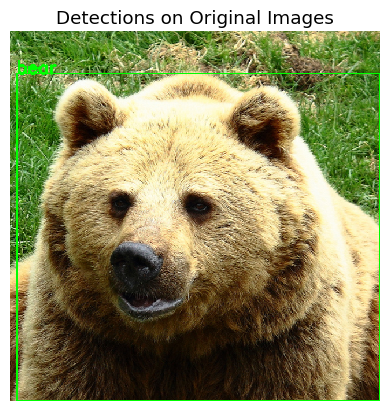

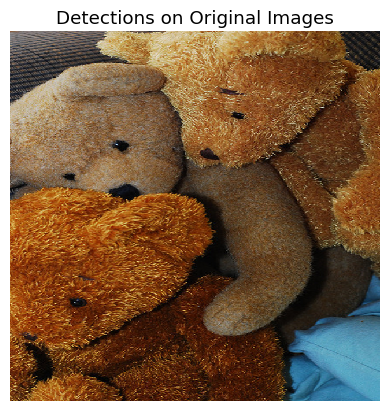

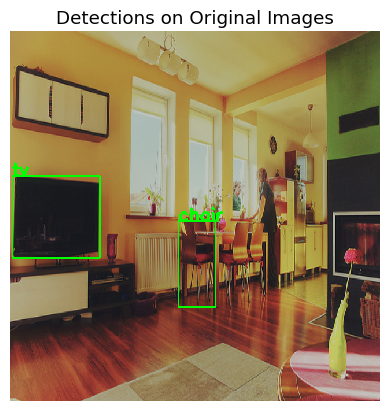

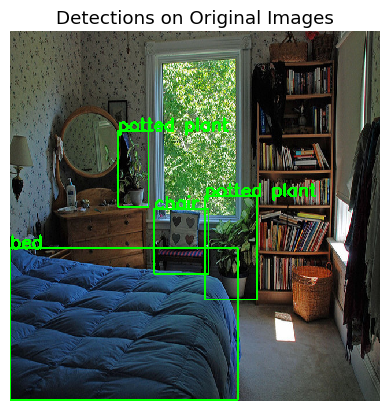

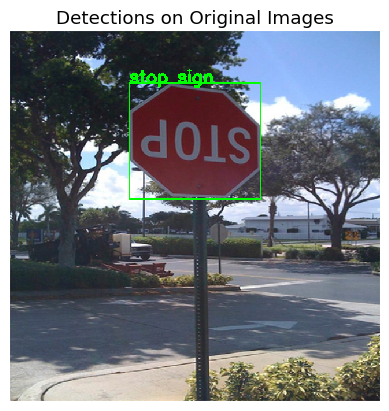

In [8]:
images, targets = next(iter(dataloader))
plot_images([images], detector, title="Detections on Original Images")


### Option 1. Using the Attacker


In [9]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import ODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

attacker_config = ODAttackerConfig(
    model=model,
    attack=attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
    target_label=None,
)
attacker = ODAttacker(config=attacker_config)
adv_imgs = attacker.execute()

Generating adversarial samples:   0%|          | 0/1 [00:00<?, ?it/s]

Target label for attack:  None
[DPATCH] untargetted attack - true labels provided


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Training Step: %i 1


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

...

c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

Training Step: %i 700


DPatch iteration:  88%|████████▊ | 700/800 [02:20<00:19,  5.03it/s]c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\

Training Step: %i 800


Generating adversarial samples: 100%|██████████| 1/1 [02:41<00:00, 161.31s/it]


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


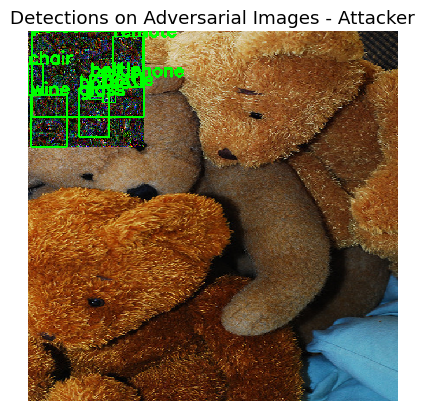

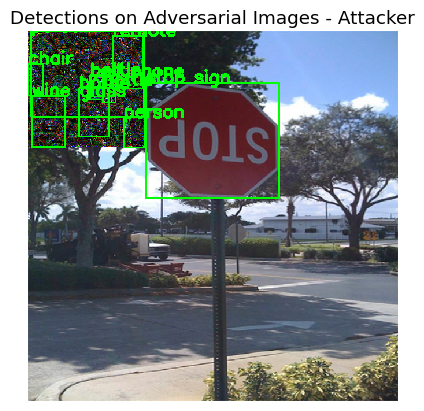

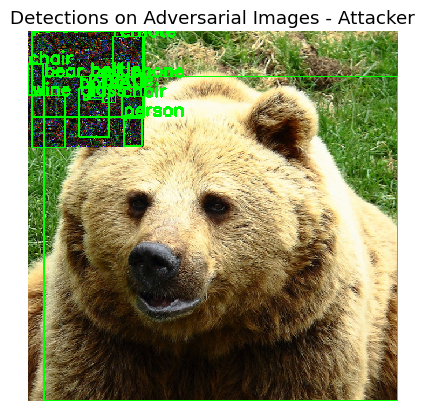

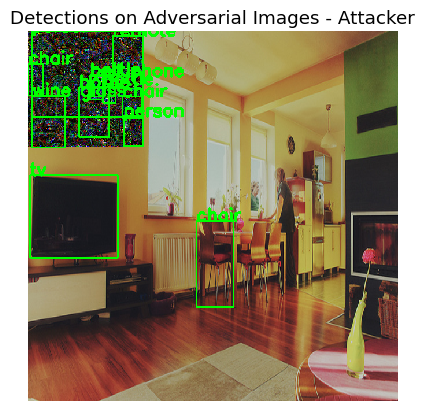

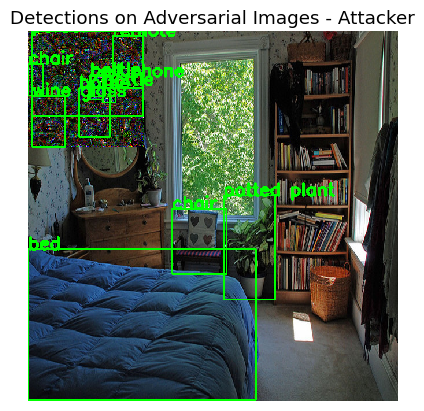

In [10]:
images = adv_imgs[0]  # Get the first batch of adversarial images
plot_images([images], detector, title="Detections on Adversarial Images - Attacker")

### Option 2. Manual Iteration

If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples. 

In [11]:
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images * 255.0).detach()               # now [0,255]
    y_formatted_list = []
    for boxes, labels, scores in zip(batch_targets_dict["boxes"],
                                      batch_targets_dict["labels"],
                                      batch_targets_dict["scores"]):
        y_formatted_list.append({
            "boxes":  boxes.cpu().numpy(),
            "labels": labels.cpu().numpy().astype(int),
            "scores": scores.cpu().numpy(),
        })
    learned_patch = attack.attack(
        x            = images_for_attack,
        y            = y_formatted_list,
        target_label = None,
        mask         = None
    )

Attacking:   0%|          | 0/1 [00:00<?, ?it/s]

[DPATCH] untargetted attack - true labels provided


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Training Step: %i 1


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

...

DPatch iteration:  75%|███████▌  | 600/800 [01:57<00:39,  5.02it/s]c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\

Training Step: %i 700


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

Training Step: %i 800


Attacking: 100%|██████████| 1/1 [03:17<00:00, 197.79s/it]


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


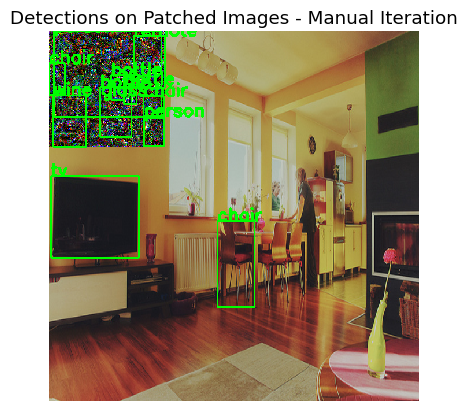

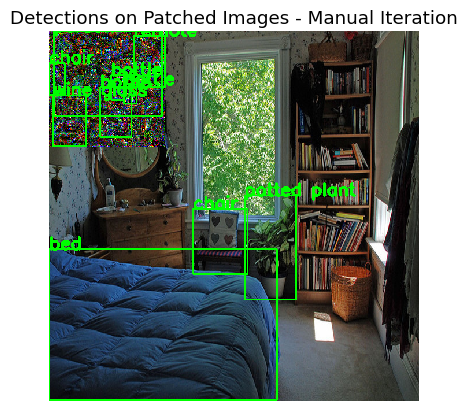

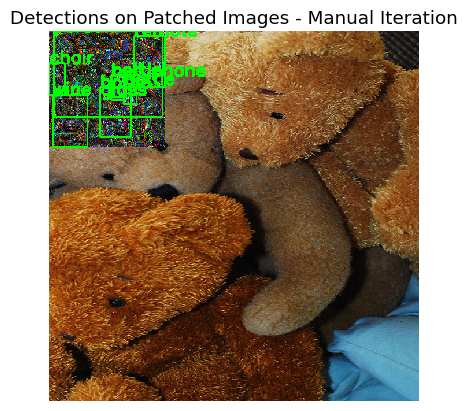

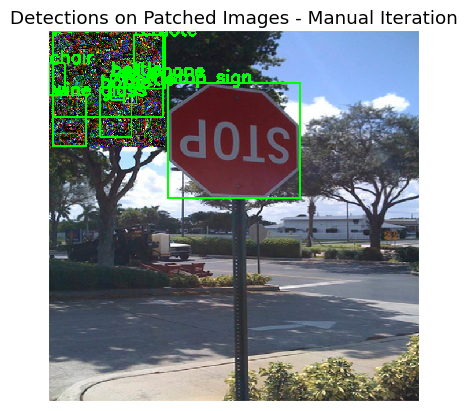

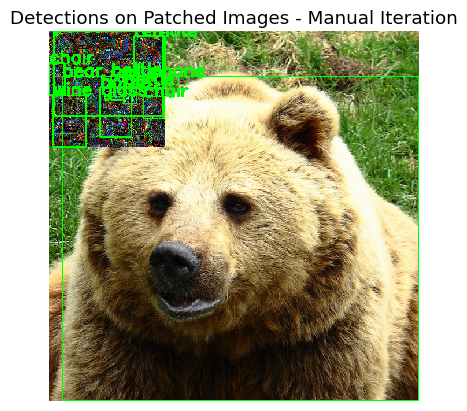

In [12]:
patched_np = attack.apply_patch(
        x              = images_for_attack,
        patch_external = learned_patch.detach().cpu().numpy(),
        random_location=False
)
patched_tensor = (patched_np / 255.0).to(detector.device)
plot_images([patched_tensor], detector, title="Detections on Patched Images - Manual Iteration")